In [279]:
import numpy as np
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [280]:
# # user functions
# def chi_source(t):
#     chi_est = 0.64
#     nu = 0.02
#     chi_0 = 0.273067
#     chi_s = chi_est * (1 - np.exp(-nu * (t - 12))) + chi_0
#     return chi_s

# def eps_donor(t):
#     eps_est = 0.524
#     nu = 0.0087
#     eps_0 = 0.6392

#     eps_d = eps_est * np.exp(-nu*t*t) + eps_0
#     return eps_d

# def eps_host(t):
#     eps_est = 0.571
#     nu = 0.0445
#     eps_0 = 0.5346

#     eps_h = eps_est * np.exp(-nu*t*t) + eps_0
#     return eps_h


# # Define the ODE function
# def ode_function(X, t, phi, ageATBMT, rho, beta, delta,P):
#     dXdt = np.zeros(4)
#     dXdt[0] = phi * eps_donor(t) * chi_source(t - ageATBMT) * P + rho * (X[0] + 2 * X[1]) - ((1 / beta) + delta) * X[0]
#     dXdt[1] = phi * (1 - eps_donor(t)) * chi_source(t - ageATBMT) * P + (1 / beta) * X[0] - (rho + delta) * X[1]
#     dXdt[2] = phi * eps_host(t) * (1 - chi_source(t - ageATBMT)) * P + rho * (X[2] + 2 * X[3]) - ((1 / beta) + delta) * X[2]
#     dXdt[3] = phi * (1 - eps_host(t)) * (1 - chi_source(t - ageATBMT)) * P + (1 / beta) * X[2] - (rho + delta) * X[3]
#     return np.array(dXdt)


# # Define the parameters
# phi = 0.01
# minageATBMT = 40
# ageATBMT = 45
# P = 1641818
# rho = 0.01
# beta = 0.01
# delta = 0.01


# # Initial conditions
# X0 = [0, 0, 1e3, 1e4]
# X2= [0, 0, 106.3357, 92984.5643]

# t_ev = [45,59]

# sol = odeint(ode_function, X0, t_ev, args=(phi, minageATBMT, rho, beta, delta, P))
# print(sol)



In [281]:
# #calculate initial conditiON
# # t_sp = (40,45)
# t_eval = [59, 69, 76, 88, 95, 102, 108, 109, 113, 119, 122, 123, 124, 141, 156, 158, 183, 212, 217, 219, 235, 261, 270, 289, 291, 306, 442, 524, 563, 566, 731]

# sol = solve_ivp(ode_function, t_span= (59,731), y0=X2, t_eval= t_eval, args=(phi, ageATBMT, rho, beta, delta, P), method='RK45')
# print(sol.y)

# # sol = solve_ivp(ode_function, t_sp, X0, t_eval= t_ev, args=(phi, eps_donor, eps_host, chi_source, minageATBMT, P, rho, beta, delta))
# # X1 = sol.y[:,0]
# # print(X1)



# # Time span
# # t_span = (58, 732)

# # #t_eval = [60, 75, 90]#np.linspace(t_span[0], t_span[1], 11)
# t_eval = np.array([59, 69, 76, 88, 95, 102, 108, 109, 113, 119, 122, 123, 124, 141, 156, 158, 183, 212, 217, 219, 235, 261, 270, 289, 291, 306, 442, 524, 563, 566, 731])

# # # Solve the ODE
# # solution = solve_ivp(ode_function, t_span, X2, t_eval=t_eval, args=(phi, eps_donor, eps_host, chi_source, ageATBMT, P, rho, beta, delta))
# # solution

# # # save as a csv file
# # np.savetxt('solutionpy.csv', solution.y, delimiter=',')
# # print(t_eval)
# # print(solution.y)


In [282]:
# Mz_total= solution.y[0]+ solution.y[1]+solution.y[2]+solution.y[3]

In [283]:
# Nf_d = (solution.y[0]+solution.y[1])/(Mz_total*chi_source(t_eval - ageATBMT))
#print(Nf_d)

In [284]:

# #plot Nf_d

# plt.scatter(t_eval-ageATBMT, Nf_d, label='Donor fraction')
# plt.xlabel('Time')
# plt.ylabel('Normalised Donor fraction')
# plt.title('Donor fraction in MZ compartment')
# plt.legend()
# plt.grid()
# plt.show()



In [285]:
import pandas as pd

#open csv file as dataframe

# df_py = pd.read_csv('solutionpy.csv', header=None)
df_r = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/mysol.csv', header=None)
df_T2 = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/mysol_T2.csv', header=None)

In [286]:
print(df_r)
print(df_T2)

         0                 1
0      NaN                 x
1      1.0  4669.11269735729
2      2.0  15190.9603285366
3      3.0  21182.9683048349
4      4.0  566384.587238155
..     ...               ...
120  120.0  75143360.3366548
121  121.0   25628177.886001
122  122.0  1212377868.23846
123  123.0  6844807.62709658
124  124.0  391212906.216937

[125 rows x 2 columns]
         0                 1
0      NaN                 x
1      1.0  678.175021657833
2      2.0  694.424721987519
3      3.0  3424.63499185563
4      4.0  28379.2469258945
..     ...               ...
120  120.0  31231.3386627657
121  121.0  4129.66093201517
122  122.0  111069.572255846
123  123.0  1041.72764944839
124  124.0  30849.7130182212

[125 rows x 2 columns]


In [287]:


#drop the first column

df_r = df_r.drop(df_r.columns[0], axis=1)
print(df_r)

df_T2 = df_T2.drop(df_T2.columns[0], axis=1)
print(df_T2)

#drop first row

df_r = df_r.drop(df_r.index[0])
print(df_r)

df_T2 = df_T2.drop(df_T2.index[0])
print(df_T2)

print(df_r[1][1])
print(df_r[1][124])

print(df_T2[1][1])
print(df_T2[1][124])



                    1
0                   x
1    4669.11269735729
2    15190.9603285366
3    21182.9683048349
4    566384.587238155
..                ...
120  75143360.3366548
121   25628177.886001
122  1212377868.23846
123  6844807.62709658
124  391212906.216937

[125 rows x 1 columns]
                    1
0                   x
1    678.175021657833
2    694.424721987519
3    3424.63499185563
4    28379.2469258945
..                ...
120  31231.3386627657
121  4129.66093201517
122  111069.572255846
123  1041.72764944839
124  30849.7130182212

[125 rows x 1 columns]
                    1
1    4669.11269735729
2    15190.9603285366
3    21182.9683048349
4    566384.587238155
5    13422.8095189647
..                ...
120  75143360.3366548
121   25628177.886001
122  1212377868.23846
123  6844807.62709658
124  391212906.216937

[124 rows x 1 columns]
                    1
1    678.175021657833
2    694.424721987519
3    3424.63499185563
4    28379.2469258945
5    1853.21609915593
..  

In [288]:
# #Create 4 arrays from R dataframe

# kihi_d = []
# kilo_d = []
# kihi_h = []
# kilo_h = []

# for i in range(1, 32):
#     kihi_d.append(df_r[1][(4*i)-3])
#     kilo_d.append(df_r[1][(4*i)-2])
#     kihi_h.append(df_r[1][(4*i)-1])
#     kilo_h.append(df_r[1][4*i])
# print(kihi_d)
# print(kilo_d)
# print(kihi_h)
# print(kilo_h)

# # Calculate Mz_total and Nf_d from R values

# Mz_total_r = []
# Nf_d_r = []

# for i in range(len(kihi_d)):
#     Mz_total_r.append(0)  # Initialize Mz_total_r with empty values
#     Nf_d_r.append(0)  # Initialize Nf_d_r with empty values
#     Mz_total_r[i] = kihi_d[i] + kilo_d[i] + kihi_h[i] + kilo_h[i]
#     Nf_d_r[i] = ((kihi_d[i] + kilo_d[i]) / (Mz_total_r[i] * chi_source(t_eval[i] - ageATBMT)))

# print(Mz_total_r)
# print(Nf_d_r)

# Define a chiSource function
def chi_source(t):
    chi_est = 0.75
    nu = 0.041
    chi_s = chi_est * (1 - np.exp(-nu * (t - 12))) 
    return chi_s

ageATBMT = 41
# Create 4 arrays from R dataframe
t_eval = [59, 69, 76, 88, 95, 102, 108, 109, 113, 119, 122, 123, 124, 141, 156, 158, 183, 212, 217, 219, 235, 261, 270, 289, 291, 306, 442, 524, 563, 566, 731]
kihi_d = []
kilo_d = []
kihi_h = []
kilo_h = []

for i in range(1, 32):
    kihi_d.append(float(df_r[1][(4*i)-3]))
    kilo_d.append(float(df_r[1][(4*i)-2]))
    kihi_h.append(float(df_r[1][(4*i)-1]))
    kilo_h.append(float(df_r[1][4*i]))
print(kihi_d)
print(kilo_d)
print(kihi_h)
print(kilo_h)

# Calculate Mz_total and Nf_d from R values

Mz_total_r = []
Nf_d_r = []
for i in range(31):
    Mz_total = kihi_d[i] + kilo_d[i] + kihi_h[i] + kilo_h[i]
    chi_value = chi_source(t_eval[i] - ageATBMT)
    if not isinstance(chi_value, (int, float)):
        raise TypeError(f"chi_source returned a non-numeric value: {chi_value}")
    Mz_total_r.append(Mz_total)
    Nf_d_r.append((kihi_d[i] + kilo_d[i]) / (Mz_total * chi_value))
print(Mz_total_r)
print(Nf_d_r)

[4669.11269735729, 13422.8095189647, 17809.712369424, 24466.7030853896, 28455.6069478083, 32648.542042146, 36416.341456947, 37059.97169751, 39679.290393393, 43743.7533298816, 45838.1245320139, 46545.6587819032, 47257.9598734288, 60147.5039274396, 72925.8328516511, 74744.7932095103, 100222.393983419, 137764.788348381, 145316.027416713, 148437.369772747, 175660.98123547, 229890.492381845, 252094.501915634, 305931.142764928, 312206.198707452, 363436.662942754, 1423694.39538192, 3233618.43936255, 4776223.20934222, 4921692.94108722, 25628177.886001]
[15190.9603285366, 109942.569492431, 220243.781097133, 473270.071496989, 650989.888931168, 847380.445773291, 1029162.86971744, 1060601.7232684, 1189511.84288232, 1392112.94846741, 1497485.24525544, 1533206.82764773, 1569226.42578962, 2227449.89039771, 2883602.88696464, 2976843.77871765, 4272535.17402323, 6144978.48346547, 6517320.78184027, 6670893.60148348, 8003227.81277842, 10630486.2139881, 11699472.4786901, 14281257.1904135, 14581472.2945689,

In [289]:
kihi_d1 = []
kilo_d1 = []
kihi_h1 = []
kilo_h1 = []

for i in range(1, 32):
    kihi_d1.append(float(df_T2[1][(4*i)-3]))
    kilo_d1.append(float(df_T2[1][(4*i)-2]))
    kihi_h1.append(float(df_T2[1][(4*i)-1]))
    kilo_h1.append(float(df_T2[1][4*i]))
print(kihi_d1)
print(kilo_d1)
print(kihi_h1)
print(kilo_h1)

# Calculate Mz_total and Nf_d from R values

Mz_total_T1 = []
Nf_d_T1 = []
for i in range(31):
    Mz_total1 = kihi_d1[i] + kilo_d1[i] + kihi_h1[i] + kilo_h1[i]
    chi_value1 = chi_source(t_eval[i] - ageATBMT)
    if not isinstance(chi_value1, (int, float)):
        raise TypeError(f"chi_source returned a non-numeric value: {chi_value}")
    Mz_total_T1.append(Mz_total1)
    Nf_d_T1.append((kihi_d1[i] + kilo_d1[i]) / (Mz_total1 * chi_value1))
print(Mz_total_T1)
print(Nf_d_T1)

[678.175021657833, 1853.21609915593, 2410.78079215983, 2999.37595101897, 3209.82791497434, 3361.43303482191, 3459.38157864111, 3473.51198703933, 3524.9213670746, 3589.40416870086, 3617.13443323326, 3625.81797889773, 3634.24452469513, 3748.06625519756, 3819.53182241031, 3827.78029701134, 3914.09465873062, 3987.50427054062, 3998.04671694031, 4002.11333607131, 4031.79442289052, 4070.64282607267, 4081.78814304742, 4102.02532271032, 4103.91850864273, 4116.82558452924, 4165.31007491305, 4163.74580631815, 4159.46849655756, 4159.07549639385, 4129.66093201517]
[694.424721987519, 4666.11459928634, 8867.68033808533, 17284.6616171864, 22422.6367477648, 27521.6873767018, 31789.8172830321, 32488.9781899215, 35246.1505259028, 39253.9833467892, 41196.7650453988, 41835.0353634488, 42468.5998428123, 52511.9278923846, 60261.4571890322, 61220.222123017, 71865.4692062299, 81540.1492351151, 82963.7989156779, 83515.1978939628, 87579.2294483709, 93026.3311950675, 94625.5926246268, 97590.9416599666, 97873.4512

In [290]:
# # Plot the results
# plt.plot(solution.t, solution.y[0], label='Donor Ki67+ cells')
# plt.plot(solution.t, solution.y[1], label='Donor Ki67- cells')
# # plt.plot(solution.t, solution.y[2], label='Host Ki67+ cells')
# # plt.plot(solution.t, solution.y[3], label='Host Ki67- cells')
# plt.plot(t_eval, kihi_d, label='Donor Ki67+ cells R')
# plt.plot(t_eval, kilo_d, label='Donor Ki67- cells R')
# # plt.plot(t_eval, kihi_h, '--', label='Host Ki67+ cells R')
# # plt.plot(t_eval, kilo_h, 'o', label='Host Ki67- cells R')
# plt.xlabel('Time')
# plt.ylabel('Cell populations')
# plt.title('Solution of the Coupled ODEs')
# plt.legend()
# plt.yscale('log')
# plt.grid()
# plt.show()

In [291]:
# # Plot the results
# plt.plot(solution.t, solution.y[2], label='Host Ki67+ cells')
# plt.plot(solution.t, solution.y[3], label='Host Ki67- cell')
# plt.plot(t_eval, kihi_h, label='Host Ki67+ cells R')
# plt.plot(t_eval, kilo_h, label='Host Ki67- cells R')
# plt.xlabel('Time')
# plt.ylabel('Cell populations')
# plt.title('Solution of the Coupled ODEs')
# plt.legend()
# plt.yscale('log')
# plt.grid()
# plt.show()

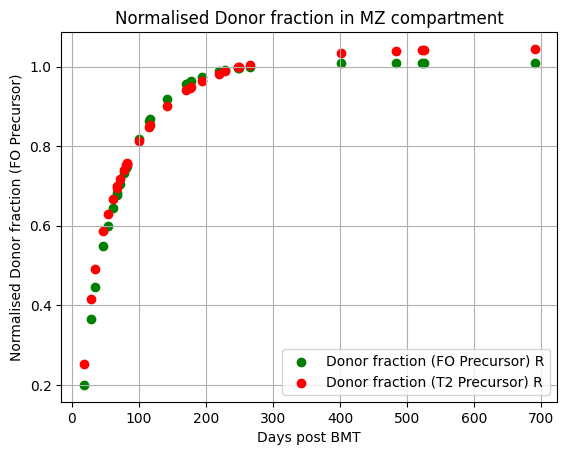

In [292]:

#plot Nf_d
t_eval_adjusted = [t - ageATBMT for t in t_eval]
# plt.scatter(t_eval-ageATBMT, Nf_d, label='Donor fraction Python')
plt.scatter(t_eval_adjusted, Nf_d_r, color= 'green', label='Donor fraction (FO Precursor) R')
plt.scatter(t_eval_adjusted, Nf_d_T1, color= 'RED', label='Donor fraction (T2 Precursor) R')
plt.xlabel('Days post BMT')
plt.ylabel('Normalised Donor fraction (FO Precursor)')
plt.title('Normalised Donor fraction in MZ compartment')
plt.legend()
plt.grid()
plt.show()

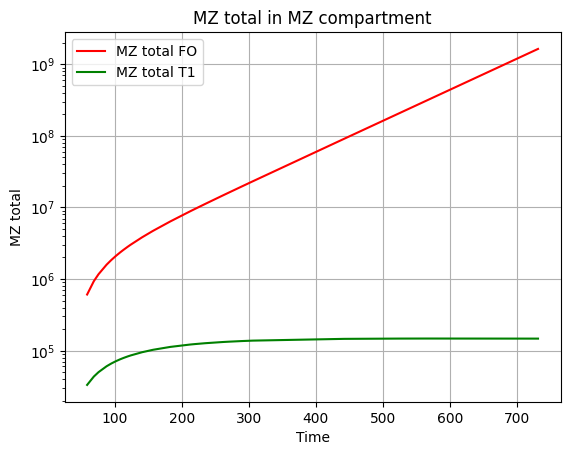

In [293]:
#plot Mz_total

# plt.scatter(t_eval-ageATBMT, Mz_total, label='MZ total Python')
plt.plot(t_eval, Mz_total_r, color= 'red', label='MZ total FO')
plt.plot(t_eval, Mz_total_T1, color= 'green', label='MZ total T1')
plt.xlabel('Time')
plt.ylabel('MZ total')
plt.yscale('log')
plt.title('MZ total in MZ compartment')
plt.legend()
plt.grid()
plt.show()

(array([0.11776212, 0.11776212, 0.14131454, 0.23552423, 0.61236301,
        0.65946786, 0.84788724, 0.94209694, 1.22472602, 1.46025025,
        1.83708903, 1.88419387, 2.07261326, 1.97840357, 2.04906084,
        1.62511722, 1.62511722, 1.24827844, 0.98920178, 0.68302028,
        0.44749604, 0.35328635, 0.14131454, 0.07065727, 0.07065727,
        0.02355242, 0.04710485, 0.        , 0.        , 0.04710485]),
 array([-0.53072474, -0.48826626, -0.44580779, -0.40334931, -0.36089083,
        -0.31843236, -0.27597388, -0.23351541, -0.19105693, -0.14859846,
        -0.10613998, -0.0636815 , -0.02122303,  0.02123545,  0.06369392,
         0.1061524 ,  0.14861088,  0.19106935,  0.23352783,  0.2759863 ,
         0.31844478,  0.36090325,  0.40336173,  0.44582021,  0.48827868,
         0.53073716,  0.57319563,  0.61565411,  0.65811259,  0.70057106,
         0.74302954]),
 <BarContainer object of 30 artists>)

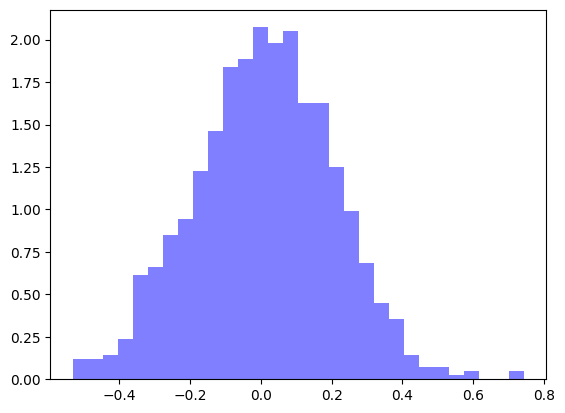

In [294]:
# plot density
x = np.random.normal(size=1000, loc=0.01, scale=0.2)

plt.hist(x, bins=30, density=True, alpha=0.5, color='b')